<div style="color:blue">

**Programming for Data Science (UFCFVQ-15-M)**

**Assignment - Part 2**

This part of the assignment focuses on using
NumPy/SciPy, Pandas, and Matplotlib/Seaborn
to combine and analyse two datasets related to bike shares.

## Overview

Part 2

  - Q2.1: explore data [20 marks]
  - Q2.2: detect and remove outliers [10 marks]
  - Q2.3: hypothesis test [10 marks]

For each of the questions Q2.1-Q2.4 there is a blank *Markdown* cell
for explanations, formulas, etc. and
a blank *code* cell for Python code.
You can add more cells.
Any explanations can be entered as Markdown or as comments with the code.
You do not have to use LaTeX (the markup language that can be used
to typeset formulas in Jupyter Notebook files).
You do have to make sure that any notation you use is clear.


## Marking Guideline
The marks for each question are indicated above.

There is not necessarily a relation between the number of marks for a question
and the amount of work required or the level of difficulty.
You may find some questions more difficult than others.

Try to answer as many questions as you can.


Q2.1

- 0: no answer, irrelevant or incorrect answer
- 1-4: insufficient and/or many mistakes
- 5-8: acceptable, but incomplete and/or substantial mistakes
- 9-12: good, substantial answer, with good explanation
- 13-16: very good, mostly complete, only minor mistake or issue with explanation
- 17-20: excellent, complete answer with clear and concise explanation

Q2.2-3

- 0: no answer, irrelevant or incorrect answer
- 1,2: insufficient and/or many mistakes
- 3,4: acceptable, but incomplete and/or substantial mistakes
- 5,6: good, substantial answer, with good explanation
- 7,8: very good, mostly complete, only minor mistake or issue with explanation
- 9,10: excellent, complete answer with clear and concise explanation

Note that the pass mark for postgraduate assessments is 50%.

<div style="color:blue">

# Part 2
To obtain good marks, you should make both your writing and your code clear, correct and concise.

</div>

In [1]:
# Importing relevant libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<div style="color:blue">

## Q2.1: Explore the Dataset to Identify an Interesting Pattern or Trend [20 marks]

Use appropriate visualisations (using, for example,  Matplotlib or Seaborn)
to illustrate your exploration.
You should include at least three visualisations as part of your exploration.
You could consider other ways to explore the data such as data summaries or
transformations.
You must include an explanation of the dataset exploration, your selected
interesting pattern or trend and your reasons for selecting it.
</div>

# For my exploration, I combined the bike-share data with the weather data using the timestamp column.

I focused on this pattern:

Bike-share use appears to be different on weekdays and weekends. On weekdays, there are clear commuting peaks in the morning and evening, while weekends are more spread across the day.

I selected this pattern because it is practical and easy to explain. Bike shares are often used for travel to work or study during the week, but weekend use may be more linked to leisure activities.

The exploration below uses three visualisations:

Average bike shares by hour of the day and weekday/weekend.
Average bike shares by temperature group.
Bike shares by season.


Number of rows and columns: (17414, 13)

Missing values:
timestamp          0
new_bike_shares    0
temperature        0
feels_like_temp    0
humidity           0
wind_speed         0
is_weekend         0
season_code        0
hour               0
date               0
month              0
day_type           0
season             0
dtype: int64

Summary of new bike shares:
count    17414.000000
mean      1143.101642
std       1085.108068
min          0.000000
25%        257.000000
50%        844.000000
75%       1671.750000
max       7860.000000
Name: new_bike_shares, dtype: float64


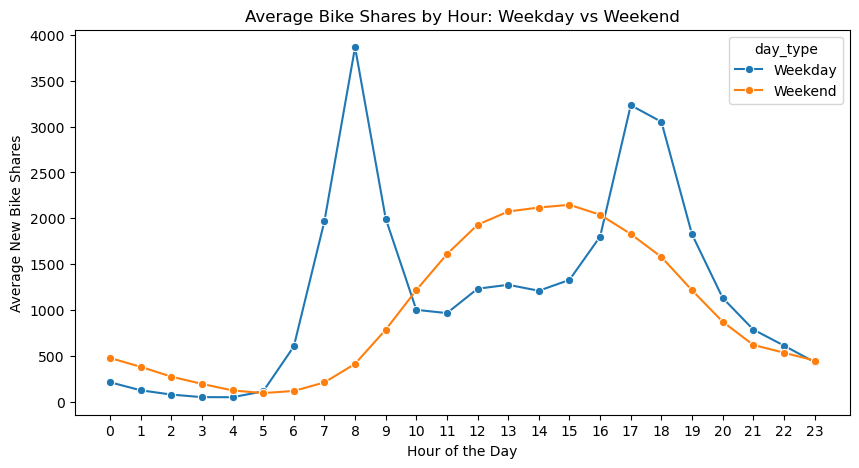

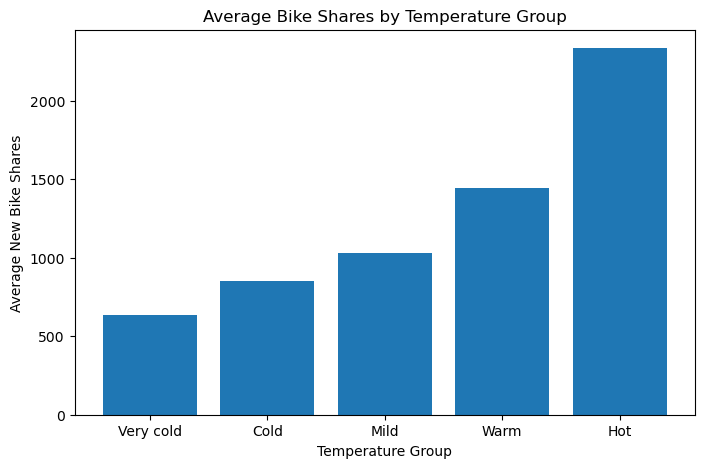

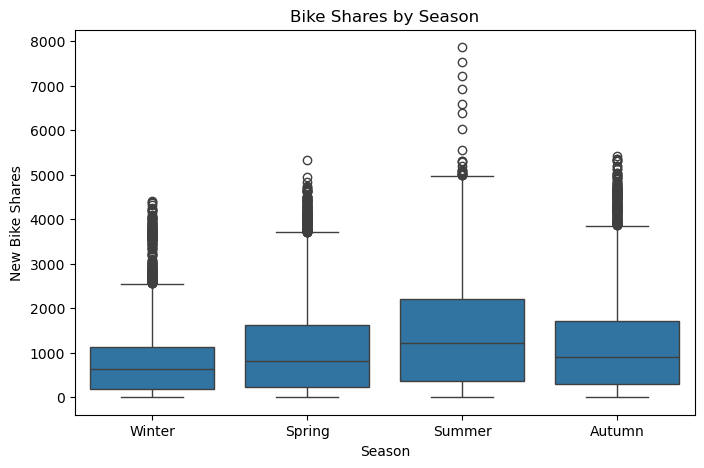

,count,mean,median,min,max
day_type,,,,,
Weekday,12444,1209.274831,927.0,9,7860
Weekend,4970,977.415694,619.0,0,4341


In [2]:
# Load the two datasets
bike = pd.read_csv("part2a.csv")
weather = pd.read_csv("part2b.csv")

# Combine both datasets using the timestamp column
bike_data = pd.merge(bike, weather, on="timestamp")

# Convert timestamp from text to datetime
bike_data["timestamp"] = pd.to_datetime(bike_data["timestamp"], dayfirst=True)

# Create useful time columns
bike_data["hour"] = bike_data["timestamp"].dt.hour
bike_data["date"] = bike_data["timestamp"].dt.date
bike_data["month"] = bike_data["timestamp"].dt.month

# Make the weekend column easier to read
bike_data["day_type"] = bike_data["is_weekend"].map({0: "Weekday", 1: "Weekend"})

# Make season labels easier to understand
season_names = {
    0: "Spring",
    1: "Summer",
    2: "Autumn",
    3: "Winter"
}
bike_data["season"] = bike_data["season_code"].map(season_names)

# Show the first few rows
bike_data.head()


# Basic summary
print("Number of rows and columns:", bike_data.shape)
print("\nMissing values:")
print(bike_data.isna().sum())

print("\nSummary of new bike shares:")
print(bike_data["new_bike_shares"].describe())

# Visualisation 1: hourly pattern by weekday/weekend
hourly_average = bike_data.groupby(["hour", "day_type"])["new_bike_shares"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_average, x="hour", y="new_bike_shares", hue="day_type", marker="o")
plt.title("Average Bike Shares by Hour: Weekday vs Weekend")
plt.xlabel("Hour of the Day")
plt.ylabel("Average New Bike Shares")
plt.xticks(range(0, 24))
plt.show()

# Visualisation 2: temperature groups
bike_data["temperature_group"] = pd.cut(
    bike_data["temperature"],
    bins=[-5, 5, 10, 15, 20, 30],
    labels=["Very cold", "Cold", "Mild", "Warm", "Hot"]
)

temperature_average = bike_data.groupby("temperature_group", observed=True)["new_bike_shares"].mean().reset_index()
temperature_average["temperature_group"] = temperature_average["temperature_group"].astype(str)

plt.figure(figsize=(8, 5))
plt.bar(temperature_average["temperature_group"], temperature_average["new_bike_shares"] )
plt.title("Average Bike Shares by Temperature Group")
plt.xlabel("Temperature Group")
plt.ylabel("Average New Bike Shares")
plt.show()

# Visualisation 3: bike shares by season
plt.figure(figsize=(8, 5))
sns.boxplot(data=bike_data, x="season", y="new_bike_shares")
plt.title("Bike Shares by Season")
plt.xlabel("Season")
plt.ylabel("New Bike Shares")
plt.show()

# A useful table for the main pattern
pattern_table = bike_data.groupby("day_type")["new_bike_shares"].agg(["count", "mean", "median", "min", "max"])
pattern_table



<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/20
</div>

<div style="color:blue">

## Q2.2: Detect and Remove Any Outliers in the Data Used for Your Interesting Pattern [10 marks]

Use an appropriate technique to detect and remove any outliers in the data
used for your interesting pattern or trend.
You must include an explanation of the detection method used, how it works,
and any outliers detected.
NOTE: there may not be any detectable outliers using the selected detection
method –
if this is the case, please state this clearly in the explanation given.
</div>




Using the IQR method to detect outliers in the new_bike_shares column.

IQR means Interquartile Range. It measures the spread of the middle 50% of the data.

The steps are:

Find Q1, the 25th percentile.
Find Q3, the 75th percentile.
Calculate IQR = Q3 - Q1.
Calculate the lower boundary as Q1 - 1.5 × IQR.
Calculate the upper boundary as Q3 + 1.5 × IQR.
Values below the lower boundary or above the upper boundary are treated as outliers.
For this dataset, the main outliers are unusually high bike-share values. These could happen during very busy commuting periods, special events, or unusually high-demand days. I removed them before doing the hypothesis test so that very extreme values did not have too much influence on the result.

Q1: 257.0
Q3: 1671.75
IQR: 1414.75
Lower limit: -1865.125
Upper limit: 3793.875
Number of outliers detected: 675
Percentage of dataset removed: 3.88 %
Original dataset size: (17414, 14)
Clean dataset size: (16739, 14)


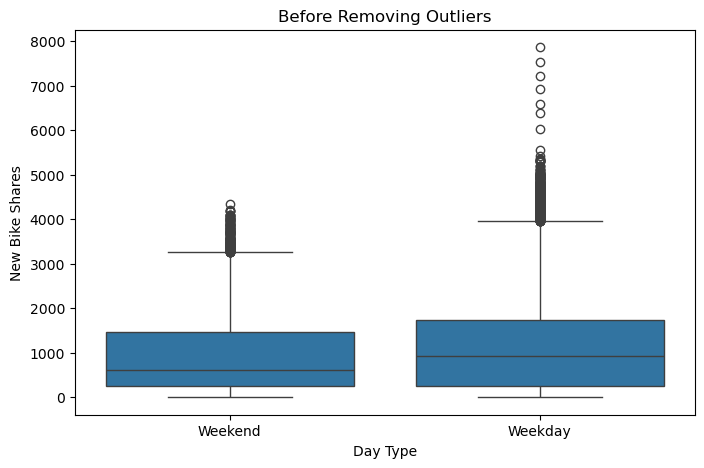

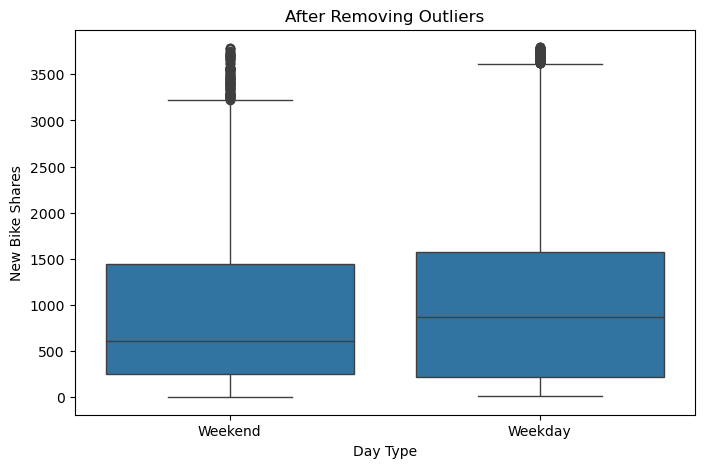

In [3]:
# Detect outliers using the IQR method
q1 = bike_data["new_bike_shares"].quantile(0.25)
q3 = bike_data["new_bike_shares"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Find the outliers
outliers = bike_data[
    (bike_data["new_bike_shares"] < lower_limit) |
    (bike_data["new_bike_shares"] > upper_limit)
]

print("Number of outliers detected:", len(outliers))
print("Percentage of dataset removed:", round(len(outliers) / len(bike_data) * 100, 2), "%")

# Create a clean dataset without outliers
bike_data_clean = bike_data[
    (bike_data["new_bike_shares"] >= lower_limit) &
    (bike_data["new_bike_shares"] <= upper_limit)
].copy()

print("Original dataset size:", bike_data.shape)
print("Clean dataset size:", bike_data_clean.shape)

# Visual check before and after removing outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=bike_data, x="day_type", y="new_bike_shares")
plt.title("Before Removing Outliers")
plt.xlabel("Day Type")
plt.ylabel("New Bike Shares")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=bike_data_clean, x="day_type", y="new_bike_shares")
plt.title("After Removing Outliers")
plt.xlabel("Day Type")
plt.ylabel("New Bike Shares")
plt.show()



<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>

<div style="color:blue">

## Q2.3: Hypothesis Test [10 marks]

Define a hypothesis using an appropriate hypothesis testing formulation.
Provide an explanation for your choice.
Using an appropriate Python library, test this hypothesis.
You must include a detailed explanation of your findings to achieve good marks for this task.
</div>

For the hypothesis test, I tested whether the average number of new bike shares is different between weekdays and weekends.

I used an **independent two-sample t-test** because I am comparing the mean of two separate groups:
- Weekday bike shares
- Weekend bike shares

I used Welch's t-test because the two groups may not have exactly the same variance.

Hypotheses:

- **Null hypothesis (H0):** There is no difference in the average number of new bike shares between weekdays and weekends.
- **Alternative hypothesis (H1):** There is a difference in the average number of new bike shares between weekdays and weekends.

I used a significance level of 0.05. This means that if the p-value is less than 0.05, I reject the null hypothesis.


Weekday mean: 1039.44
Weekend mean: 954.26
T-statistic: 5.6518
P-value: 1.635050317688392e-08
Conclusion: Reject the null hypothesis.
There is statistical evidence that average bike shares are different on weekdays and weekends.


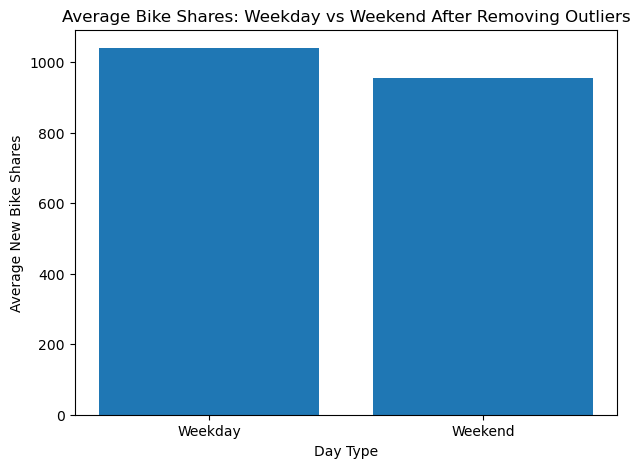

In [4]:
# Split the cleaned data into weekday and weekend groups
weekday_shares = bike_data_clean[bike_data_clean["day_type"] == "Weekday"]["new_bike_shares"]
weekend_shares = bike_data_clean[bike_data_clean["day_type"] == "Weekend"]["new_bike_shares"]

# Run Welch's independent t-test
t_statistic, p_value = stats.ttest_ind(weekday_shares, weekend_shares, equal_var=False)

print("Weekday mean:", round(weekday_shares.mean(), 2))
print("Weekend mean:", round(weekend_shares.mean(), 2))
print("T-statistic:", round(t_statistic, 4))
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject the null hypothesis.")
    print("There is statistical evidence that average bike shares are different on weekdays and weekends.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to say that average bike shares are different on weekdays and weekends.")

# Plot the cleaned comparison
clean_means = bike_data_clean.groupby("day_type")["new_bike_shares"].mean()

plt.figure(figsize=(7, 5))
plt.bar(clean_means.index, clean_means.values)
plt.title("Average Bike Shares: Weekday vs Weekend After Removing Outliers")
plt.xlabel("Day Type")
plt.ylabel("Average New Bike Shares")
plt.show()



<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>